## Section 1 · Imports & Load Preprocessed Data

In [2]:
import os, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_recall_curve, average_precision_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Section 2 · Dataset & DataLoaders

In [7]:
BASE_DIR  = Path('/kaggle/input/notebooks/esraa320230011/preprocessing-f')
SPEC_DIR  = BASE_DIR / 'specs'

print('Files available in input:')
for f in sorted(BASE_DIR.iterdir()):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    tag  = f'({size:.1f} MB)' if f.is_file() else '(folder)'
    print(f'  {f.name:40s}  {tag}')

npy_files = sorted(SPEC_DIR.glob('*.npy'))
print(f'\nSpec files found: {len(npy_files)}')
if len(npy_files) == 0:
    raise FileNotFoundError(f'No .npy files found in {SPEC_DIR}. '
                             'Check that the correct notebook version is attached as input.')

Files available in input:
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
  __notebook__.ipynb                        (0.6 MB)
  __output__.json                           (0.0 MB)
  __results__.html                          (0.4 MB)
  __results___files                         (folder)
  config.json                               (0.0 MB)
  custom.css                                (0.0 MB)
  manifest.csv                              (1.9 MB)
  sanity_check.png                          (0.1 MB)
  specs                                     (folder)

Spec files found: 28992


In [8]:
with open(BASE_DIR / 'config.json') as f:
    CFG = json.load(f)

CFG['epochs']   = 50
CFG['patience'] = 10
CFG['bs']       = 32

print('Config loaded:')
for k, v in CFG.items():
    print(f'  {k}: {v}')


manifest = pd.read_csv(BASE_DIR / 'manifest.csv')
print(f'Manifest rows    : {len(manifest)}')
print(f'Manifest columns : {list(manifest.columns)}')

label_col = None
for col in manifest.columns:
    if any(kw in col.lower() for kw in ['label', 'class', 'target']):
        label_col = col
        break
if label_col is None:
    raise ValueError('No label column found in manifest.csv')
print(f'Label column     : {label_col}')

manifest['path'] = manifest['path'].apply(
    lambda p: str(SPEC_DIR / Path(p).name)
)

exists_mask = manifest['path'].apply(lambda p: Path(p).exists())
print(f'Files found on disk: {exists_mask.sum()} / {len(manifest)}')
manifest = manifest[exists_mask].reset_index(drop=True)

print(f'\nClass distribution:')
print(manifest[label_col].value_counts().rename({0: 'Interictal', 1: 'Ictal'}))
print(f'Seizure % : {100 * manifest[label_col].mean():.2f}%')

sample_spec = np.load(manifest['path'].iloc[0])
print(f'Single spec shape : {sample_spec.shape}')   # expected (n_ch, F, T)
n_ch_spec, F_bins, T_frames = sample_spec.shape
print(f'  Channels    : {n_ch_spec}')
print(f'  Freq bins   : {F_bins}')
print(f'  Time frames : {T_frames}')

Config loaded:
  fs: 256
  epoch_sec: 4
  overlap_ratio: 0.5
  preictal_sec: 30
  bp_low: 0.5
  bp_high: 40.0
  notch_freq: 60.0
  notch_quality: 30
  bands: {'delta': [0.5, 4], 'theta': [4, 8], 'alpha': [8, 13], 'beta': [13, 30], 'gamma': [30, 40]}
  spec_nperseg: 128
  spec_noverlap: 64
  spec_n_mels: 64
  val_split: 0.15
  test_split: 0.15
  batch_size: 32
  epochs: 50
  patience: 10
  channel_mode: all
  epoch_samples: 1024
  step_samples: 512
  n_ch_spec: 23
  bs: 32
Manifest rows    : 28992
Manifest columns : ['path', 'label', 'case', 'file']
Label column     : label
Files found on disk: 28992 / 28992

Class distribution:
label
Interictal    28957
Ictal            35
Name: count, dtype: int64
Seizure % : 0.12%
Single spec shape : (23, 64, 15)
  Channels    : 23
  Freq bins   : 64
  Time frames : 15


## Section 3 · Dataset Class

In [10]:
class EEGManifestDataset(Dataset):
    def __init__(self, df, label_col, augment=False):
        self.paths   = df['path'].values
        self.labels  = df[label_col].values.astype(np.int64)
        self.augment = augment

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        spec  = torch.from_numpy(np.load(self.paths[idx])).float()  # (C, F, T)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.augment:
            spec = self._spec_augment(spec)
        return spec, label

    @staticmethod
    def _spec_augment(x, freq_param=8, time_param=8):
        x = x.clone()
        _, F, T = x.shape
        f  = torch.randint(0, freq_param + 1, (1,)).item()
        f0 = torch.randint(0, max(F - f, 1), (1,)).item()
        x[:, f0:f0+f, :] = 0.0
        t  = torch.randint(0, time_param + 1, (1,)).item()
        t0 = torch.randint(0, max(T - t, 1), (1,)).item()
        x[:, :, t0:t0+t] = 0.0
        return x

## Section 4 · CNN Architecture

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            # Pool only freq axis to avoid collapsing tiny time dimension
            layers.append(nn.MaxPool2d(kernel_size=(2, 1)))
        if dropout > 0.0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)



class EEG_CNN(nn.Module):
    """
    Architecture:
      4 × ConvBlock  →  Global Average Pooling
      MLP head: 512 → BN → ReLU → Dropout → 256 → BN → ReLU → Dropout → 2
    """
    def __init__(self, in_channels, n_classes=2, base_filters=32, dropout=0.3):
        super().__init__()
        c = base_filters
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, c,  pool=True, dropout=0.0),
            ConvBlock(c,    c*2,       pool=True, dropout=0.1),
            ConvBlock(c*2,  c*4,       pool=True, dropout=0.1),
            ConvBlock(c*4,  c*8,       pool=True, dropout=0.2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c*8, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout/2),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


print('CNN architecture defined.')

CNN architecture defined.


## Section 5 · Loss & Optimizers & Scheduler

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        a   = torch.where(targets == 1,
                          torch.full_like(ce, self.alpha),
                          torch.full_like(ce, 1 - self.alpha))
        return (a * (1 - p_t) ** self.gamma * ce).mean()


OPTIMIZER_NAME = 'adamw'   # 'adam' | 'adamw' | 'nadam' | 'adamax' | 'sgd_mom'
LR = 1e-3
WD = 1e-4

def get_optimizer(name, model):
    p = model.parameters()
    if name == 'adam'   : return Adam(p, lr=LR, weight_decay=WD)
    if name == 'adamw'  : return AdamW(p, lr=LR, weight_decay=WD, betas=(0.9, 0.999))
    if name == 'nadam'  : return torch.optim.NAdam(p, lr=LR, weight_decay=WD)
    if name == 'adamax' : return torch.optim.Adamax(p, lr=LR, weight_decay=WD)
    if name == 'sgd_mom': return torch.optim.SGD(p, lr=LR, momentum=0.9,
                                                  weight_decay=WD, nesterov=True)
    raise ValueError(name)

print(f'Optimizer : {OPTIMIZER_NAME.upper()} | LR={LR} | WD={WD}')

Optimizer : ADAMW | LR=0.001 | WD=0.0001


## Section 6 · Training 

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for spec_b, lab_b in loader:
        spec_b, lab_b = spec_b.to(DEVICE), lab_b.to(DEVICE)
        logits = model(spec_b)
        loss   = criterion(logits, lab_b)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * lab_b.size(0)
        correct    += (logits.argmax(1) == lab_b).sum().item()
        total      += lab_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_probs, all_labels = [], []
    for spec_b, lab_b in loader:
        spec_b, lab_b = spec_b.to(DEVICE), lab_b.to(DEVICE)
        logits = model(spec_b)
        loss   = criterion(logits, lab_b)
        total_loss += loss.item() * lab_b.size(0)
        correct    += (logits.argmax(1) == lab_b).sum().item()
        total      += lab_b.size(0)
        all_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        all_labels.extend(lab_b.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss / total, correct / total, auc, all_probs, all_labels


print('train_one_epoch and evaluate defined.')

train_one_epoch and evaluate defined.


## Section 7 · K-Fold Cross-Validation Training

In [15]:
N_FOLDS = 5
BS      = CFG['bs']
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(manifest, manifest[label_col]), 1):
    print(f'\n{"─"*60}')
    print(f'  FOLD {fold}/{N_FOLDS}')
    print(f'{"─"*60}')

    train_df = manifest.iloc[train_idx].reset_index(drop=True)
    val_df   = manifest.iloc[val_idx].reset_index(drop=True)

    print(f'Train: {len(train_df):5d}  Ictal={train_df[label_col].sum():4d} '
          f'({100*train_df[label_col].mean():.1f}%)')
    print(f'Val  : {len(val_df):5d}  Ictal={val_df[label_col].sum():4d} '
          f'({100*val_df[label_col].mean():.1f}%)')

    # WeightedRandomSampler 
    y_tr    = train_df[label_col].values
    counts  = np.bincount(y_tr)
    weights = (1.0 / counts)[y_tr]
    sampler = WeightedRandomSampler(torch.DoubleTensor(weights), len(y_tr), replacement=True)

    train_loader = DataLoader(
        EEGManifestDataset(train_df, label_col, augment=True),
        batch_size=BS, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        EEGManifestDataset(val_df, label_col, augment=False),
        batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)

    spec_b, _ = next(iter(train_loader))
    n_ch_spec = spec_b.shape[1]

    model     = EEG_CNN(in_channels=n_ch_spec).to(DEVICE)
    optimizer = get_optimizer(OPTIMIZER_NAME, model)
    criterion = FocalLoss(gamma=2.0, alpha=0.75)
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable params : {total_params:,}')

    # Training loop
    best_ap    = 0.0
    best_auc   = 0.0
    best_rec   = 0.0
    patience_c = 0
    best_state = None

    for epoch in range(1, CFG['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_auc, probs, labels_v = evaluate(model, val_loader, criterion)
        scheduler.step()

        # Ictal-focused metrics 
        preds      = (np.array(probs) > 0.5).astype(int)
        labels_arr = np.array(labels_v)

        ictal_recall    = 0.0
        ictal_precision = 0.0
        if labels_arr.sum() > 0:
            ictal_recall    = (preds[labels_arr == 1] == 1).mean()
            ictal_precision = (labels_arr[preds == 1] == 1).mean() if preds.sum() > 0 else 0.0

        ap = average_precision_score(labels_arr, probs) if labels_arr.sum() > 0 else 0.0

        if ap > best_ap:
            best_ap    = ap
            best_auc   = va_auc
            best_rec   = ictal_recall
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_c = 0
        else:
            patience_c += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep {epoch:3d} | loss={va_loss:.4f} | acc={va_acc:.3f} '
                  f'| AUC={va_auc:.4f} | AP={ap:.4f} '
                  f'| Recall(Ictal)={ictal_recall:.3f} | Prec(Ictal)={ictal_precision:.3f}')

        if patience_c >= CFG['patience']:
            print(f'  Early stopping at epoch {epoch}')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'\n  ✔ Fold {fold} best → AUC={best_auc:.4f} | AP={best_ap:.4f} | Ictal Recall={best_rec:.3f}')
    fold_results.append({'fold': fold, 'auc': best_auc, 'ap': best_ap, 'ictal_recall': best_rec})


# Cross-validation summary 
print(f'\n{"="*60}')
print('  K-FOLD CROSS-VALIDATION SUMMARY')
print(f'{"="*60}')
res_df = pd.DataFrame(fold_results)
for metric in ['auc', 'ap', 'ictal_recall']:
    print(f'  {metric:>14s} : {res_df[metric].mean():.4f} ± {res_df[metric].std():.4f}')
print(f'{"="*60}')


────────────────────────────────────────────────────────────
  FOLD 1/5
────────────────────────────────────────────────────────────
Train: 23193  Ictal=  28 (0.1%)
Val  :  5799  Ictal=   7 (0.1%)
Trainable params : 1,443,938
  Ep   1 | loss=0.0004 | acc=0.999 | AUC=0.9991 | AP=0.7850 | Recall(Ictal)=0.714 | Prec(Ictal)=0.833
  Ep   5 | loss=0.0002 | acc=1.000 | AUC=0.9992 | AP=0.8835 | Recall(Ictal)=0.857 | Prec(Ictal)=1.000
  Ep  10 | loss=0.0004 | acc=1.000 | AUC=0.9995 | AP=0.8956 | Recall(Ictal)=0.857 | Prec(Ictal)=0.857
  Early stopping at epoch 12

  ✔ Fold 1 best → AUC=0.9998 | AP=0.9196 | Ictal Recall=0.571

────────────────────────────────────────────────────────────
  FOLD 2/5
────────────────────────────────────────────────────────────
Train: 23193  Ictal=  28 (0.1%)
Val  :  5799  Ictal=   7 (0.1%)
Trainable params : 1,443,938
  Ep   1 | loss=0.0005 | acc=1.000 | AUC=0.9975 | AP=0.8662 | Recall(Ictal)=0.857 | Prec(Ictal)=1.000
  Ep   5 | loss=0.0001 | acc=1.000 | AUC=1.000

## Section 8 · Training Curves (K-Fold Summary)

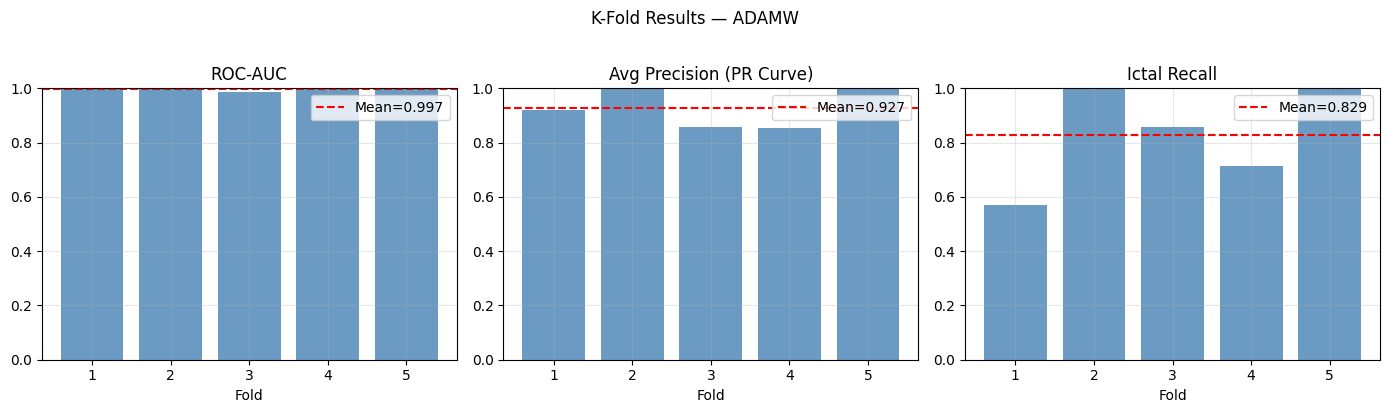

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['auc', 'ap', 'ictal_recall']
titles  = ['ROC-AUC', 'Avg Precision (PR Curve)', 'Ictal Recall']

for ax, metric, title in zip(axes, metrics, titles):
    values = res_df[metric].values
    ax.bar(range(1, N_FOLDS + 1), values, color='steelblue', alpha=0.8)
    ax.axhline(values.mean(), color='red', linestyle='--',
               label=f'Mean={values.mean():.3f}')
    ax.set(title=title, xlabel='Fold', ylim=(0, 1))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'K-Fold Results — {OPTIMIZER_NAME.upper()}', y=1.02)
plt.tight_layout()
plt.show()

## Section 9 · Final Evaluation

Test Accuracy        : 0.9998
Test AUC             : 1.0000
Test Avg Precision   : 1.0000
Test F1-macro        : 0.9666
Ictal Recall         : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Interictal       1.00      1.00      1.00      5791
       Ictal       0.88      1.00      0.93         7

    accuracy                           1.00      5798
   macro avg       0.94      1.00      0.97      5798
weighted avg       1.00      1.00      1.00      5798



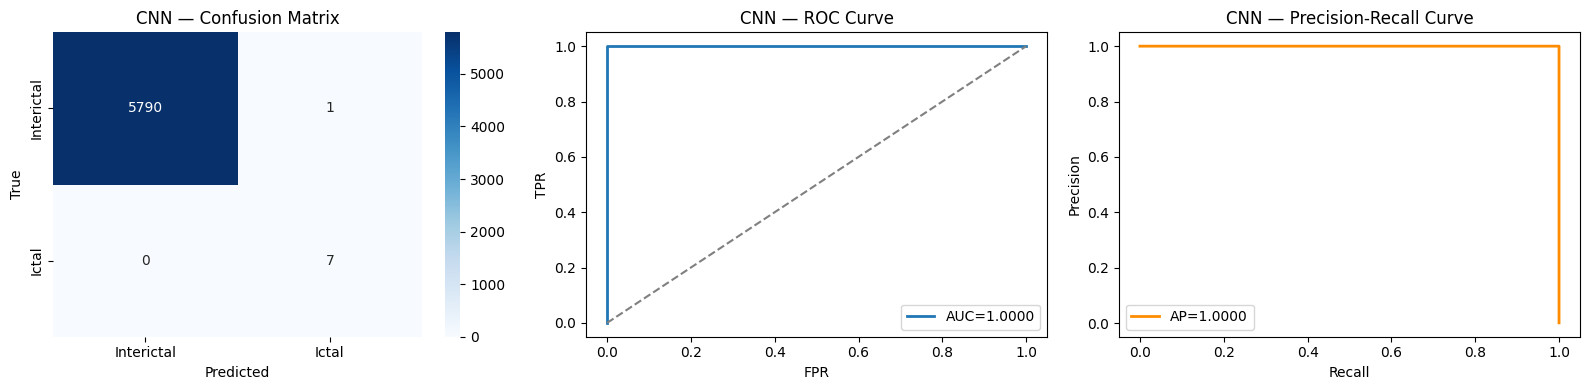

In [17]:
# Build a held-out test set from last fold's val_df 
test_loader = DataLoader(
    EEGManifestDataset(val_df, label_col, augment=False),
    batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)

_, acc, auc, probs, labels_te = evaluate(model, test_loader, criterion)
preds = (np.array(probs) > 0.5).astype(int)
labels_arr = np.array(labels_te)

ap = average_precision_score(labels_arr, probs) if labels_arr.sum() > 0 else 0.0

print(f'Test Accuracy        : {acc:.4f}')
print(f'Test AUC             : {auc:.4f}')
print(f'Test Avg Precision   : {ap:.4f}')
print(f'Test F1-macro        : {f1_score(labels_te, preds, average="macro"):.4f}')
ictal_recall = (preds[labels_arr == 1] == 1).mean() if labels_arr.sum() > 0 else 0.0
print(f'Ictal Recall         : {ictal_recall:.4f}')
print('\nClassification Report:')
print(classification_report(labels_te, preds, target_names=['Interictal', 'Ictal']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion Matrix
cm = confusion_matrix(labels_te, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Interictal', 'Ictal'],
            yticklabels=['Interictal', 'Ictal'], ax=axes[0])
axes[0].set(title='CNN — Confusion Matrix', xlabel='Predicted', ylabel='True')

# ROC Curve
fpr, tpr, _ = roc_curve(labels_te, probs)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC={auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set(title='CNN — ROC Curve', xlabel='FPR', ylabel='TPR')
axes[1].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(labels_te, probs)
axes[2].plot(rec, prec, lw=2, color='darkorange', label=f'AP={ap:.4f}')
axes[2].set(title='CNN — Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 10 · Save Model

In [18]:
out_dir = Path('/kaggle/working')
torch.save(model.state_dict(), out_dir / 'cnn_best.pt')
print(f'Saved → {out_dir}/cnn_best.pt')

Saved → /kaggle/working/cnn_best.pt
